In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

HIDDEN_SIZES   = [256, 128]  # original hidden layer widths
PRUNE_PERCENT  = 50          # % of neurons to remove from each hidden layer
TRAIN_EPOCHS   = 5
RETRAIN_EPOCHS = 3
BATCH_SIZE     = 128
LR             = 1e-3
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

Using device: cuda


#Loading MNIST Dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Train: {len(train_dataset):,}  |  Test: {len(test_dataset):,}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.11MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.98MB/s]

Train: 60,000  |  Test: 10,000


# Defining the Network

In [3]:
def build_model(hidden_sizes):
    layers = []
    in_dim = 784
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU()]
        in_dim = h
    layers.append(nn.Linear(in_dim, 10))
    return nn.Sequential(*layers).to(DEVICE)

model = build_model(HIDDEN_SIZES)
print(model)
print(f"\nTotal params: {sum(p.numel() for p in model.parameters()):,}")

Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)

Total params: 235,146


# Training & Evaluation Helpers

In [4]:
def train_one_epoch(model, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.view(x.size(0), -1).to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def evaluate(model):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.view(x.size(0), -1).to(DEVICE), y.to(DEVICE)
            correct += (model(x).argmax(1) == y).sum().item()
            total   += y.size(0)
    return 100 * correct / total

def train_loop(model, epochs, tag=""):
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    history = []
    for epoch in range(1, epochs + 1):
        loss = train_one_epoch(model, optimizer, criterion)
        acc  = evaluate(model)
        history.append(acc)
        print(f"[{tag}] epoch {epoch}/{epochs}  loss={loss:.4f}  acc={acc:.2f}%")
    return history

# Training the original Model

In [5]:
print(f"Training original model {HIDDEN_SIZES}...\n")
original_model = build_model(HIDDEN_SIZES)
orig_history   = train_loop(original_model, TRAIN_EPOCHS, tag="original")
orig_acc       = orig_history[-1]
n_orig         = sum(p.numel() for p in original_model.parameters())

print(f"\nFinal accuracy : {orig_acc:.2f}%")
print(f"Total params   : {n_orig:,}")

Training original model [256, 128]...

[original] epoch 1/5  loss=0.2643  acc=96.41%
[original] epoch 2/5  loss=0.1029  acc=96.91%
[original] epoch 3/5  loss=0.0682  acc=97.87%
[original] epoch 4/5  loss=0.0510  acc=97.68%
[original] epoch 5/5  loss=0.0413  acc=97.78%

Final accuracy : 97.78%
Total params   : 235,146


# Pruning Weak Neurons

In [6]:
def prune_model(model, prune_pct):
    linears        = [m for m in model if isinstance(m, nn.Linear)]
    hidden_linears = linears[:-1]
    surviving_idx  = []

    for i, layer in enumerate(hidden_linears):
        next_layer = linears[i + 1]
        # Score each neuron by the L2 norm of its outgoing weights
        scores = next_layer.weight.data.norm(dim=0).cpu().numpy()
        n_keep = max(1, int(len(scores) * (1 - prune_pct / 100)))
        keep   = np.sort(np.argsort(scores)[::-1][:n_keep])
        surviving_idx.append(keep)
        print(f"  Layer {i+1}: {len(scores)} neurons → keep {n_keep}  (removed {len(scores)-n_keep})")

    pruned_sizes = [len(idx) for idx in surviving_idx]
    pruned       = build_model(pruned_sizes)
    pruned_lins  = [m for m in pruned if isinstance(m, nn.Linear)]

    prev_keep = None
    for i, keep in enumerate(surviving_idx):
        src, dst = hidden_linears[i], pruned_lins[i]
        if prev_keep is None:
            dst.weight.data = src.weight.data[keep, :]
        else:
            dst.weight.data = src.weight.data[np.ix_(keep, prev_keep)]
        dst.bias.data = src.bias.data[keep]
        prev_keep = keep

    pruned_lins[-1].weight.data = linears[-1].weight.data[:, prev_keep]
    pruned_lins[-1].bias.data   = linears[-1].bias.data.clone()

    return pruned, pruned_sizes


print(f"Pruning {PRUNE_PERCENT}% of neurons...\n")
pruned_model, pruned_sizes = prune_model(original_model, PRUNE_PERCENT)

acc_just_pruned = evaluate(pruned_model)
n_pruned        = sum(p.numel() for p in pruned_model.parameters())

print(f"\nPruned architecture          : {pruned_sizes}")
print(f"Params after pruning         : {n_pruned:,}  ({100*n_pruned/n_orig:.1f}% of original)")
print(f"Accuracy before retraining   : {acc_just_pruned:.2f}%")

Pruning 50% of neurons...

  Layer 1: 256 neurons → keep 128  (removed 128)
  Layer 2: 128 neurons → keep 64  (removed 64)

Pruned architecture          : [128, 64]
Params after pruning         : 109,386  (46.5% of original)
Accuracy before retraining   : 90.73%


# Retraining the Pruned Model

In [7]:
print(f"Retraining pruned model {pruned_sizes}...\n")
pruned_history = train_loop(pruned_model, RETRAIN_EPOCHS, tag="pruned")
retrained_acc  = pruned_history[-1]

Retraining pruned model [128, 64]...

[pruned] epoch 1/3  loss=0.0463  acc=97.97%
[pruned] epoch 2/3  loss=0.0304  acc=98.02%
[pruned] epoch 3/3  loss=0.0247  acc=97.74%


# Summary of the Experiment

In [8]:
print("=" * 50)
print(f"  Original  {HIDDEN_SIZES}  | params: {n_orig:>7,} | acc: {orig_acc:.2f}%")
print(f"  Pruned    {pruned_sizes}     | params: {n_pruned:>7,} | acc: {retrained_acc:.2f}%")
print(f"  Param reduction : {100*(1 - n_pruned/n_orig):.1f}%")
print(f"  Accuracy drop   : {orig_acc - retrained_acc:.2f}%")
print("=" * 50)

  Original  [256, 128]  | params: 235,146 | acc: 97.78%
  Pruned    [128, 64]     | params: 109,386 | acc: 97.74%
  Param reduction : 53.5%
  Accuracy drop   : 0.04%


Result Plotting

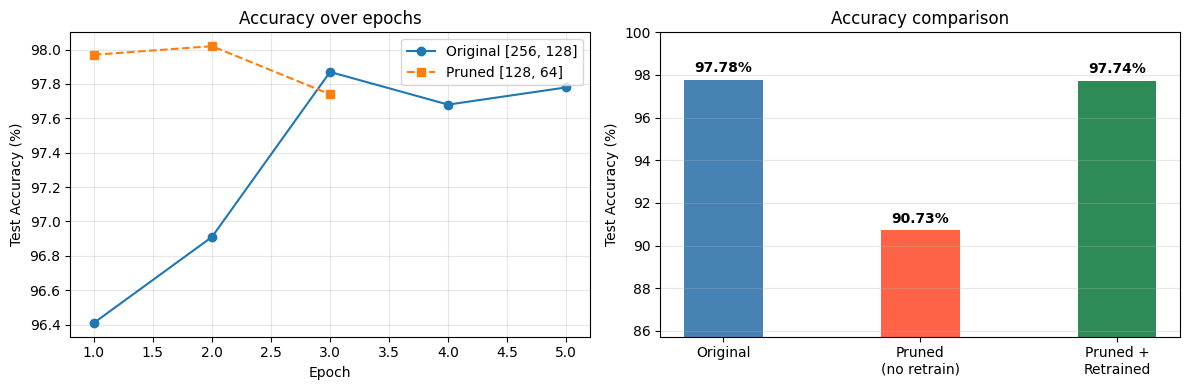

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy curves
ax = axes[0]
ax.plot(range(1, TRAIN_EPOCHS + 1),   orig_history,   "o-",  label=f"Original {HIDDEN_SIZES}")
ax.plot(range(1, RETRAIN_EPOCHS + 1), pruned_history, "s--", label=f"Pruned {pruned_sizes}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Accuracy over epochs")
ax.legend()
ax.grid(True, alpha=0.3)

# Bar chart
ax2 = axes[1]
labels = ["Original", "Pruned\n(no retrain)", "Pruned +\nRetrained"]
accs   = [orig_acc, acc_just_pruned, retrained_acc]
bars   = ax2.bar(labels, accs, color=["steelblue","tomato","seagreen"], width=0.4)
ax2.set_ylim(min(accs) - 5, 100)
ax2.set_ylabel("Test Accuracy (%)")
ax2.set_title("Accuracy comparison")
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{acc:.2f}%", ha="center", va="bottom", fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()